In [55]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import hashlib
import shutil
import cv2
import pandas as pd
import seaborn as sns

In [ ]:
TARGET_CLASSES = ["apple", "banana", "orange"]

## DATASET FRUIT-262

https://www.kaggle.com/datasets/aelchimminut/fruits262

In [ ]:
SOURCE_PATH = "DatasetRaw/Fruit-262"
TARGET_PATH = "DatasetRaw/FilteredDataset/Fruit-262-FIL"

os.makedirs(TARGET_PATH, exist_ok=True)

for cls in os.listdir(SOURCE_PATH):
    cls_lower = cls.lower()

    if cls_lower in TARGET_CLASSES:
        src_folder = os.path.join(SOURCE_PATH, cls)
        dst_folder = os.path.join(TARGET_PATH, cls)

        shutil.copytree(src_folder, dst_folder, dirs_exist_ok=True)
        print(f"Copied Class: {cls}")

Copied Class: apple
Copied Class: banana
Copied Class: orange


## FRUIT AND VEGIE DATASET

https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

In [41]:
TARGET_CLASSES = ["apple", "banana", "orange"]
SOURCE_BASE = "DatasetRaw/Dataset" 
TARGET_BASE = "DatasetRaw/FilteredDataset/Fruit-and-Veg-FIL"

os.makedirs(TARGET_BASE, exist_ok=True)
sub_sets = ["train", "test", "validation"]

for s_set in sub_sets:
    set_path = os.path.join(SOURCE_BASE, s_set)
    
    if not os.path.exists(set_path):
        print(f"Folder {s_set} not found")
        continue

    for cls in os.listdir(set_path):
        cls_lower = cls.lower().strip()

        if cls_lower in TARGET_CLASSES:
            src_folder = os.path.join(set_path, cls)
            dst_folder = os.path.join(TARGET_BASE, cls_lower)
            
            os.makedirs(dst_folder, exist_ok=True)

            files = os.listdir(src_folder)
            count = 0
            for file_name in files:
                src_file = os.path.join(src_folder, file_name)
                
                new_file_name = f"{s_set}_{file_name}"
                dst_file = os.path.join(dst_folder, new_file_name)
                
                if os.path.isfile(src_file):
                    shutil.copy2(src_file, dst_file)
                    count += 1
            
            print(f"[{s_set.upper()}] Moved {count} pictures from class: {cls}")

[TRAIN] Moved 67 pictures from class: apple
[TRAIN] Moved 75 pictures from class: banana
[TRAIN] Moved 69 pictures from class: orange
[TEST] Moved 7 pictures from class: apple
[TEST] Moved 6 pictures from class: banana
[TEST] Moved 10 pictures from class: orange
[VALIDATION] Moved 7 pictures from class: apple
[VALIDATION] Moved 7 pictures from class: banana
[VALIDATION] Moved 9 pictures from class: orange


In [ ]:
hashes = {}
corrupt_count = 0
duplicate_count = 0
total_scanned = 0

def get_hash(path):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

for root, _, files in os.walk(TARGET_BASE):
    for file in files:
        path = os.path.join(root, file)
        total_scanned += 1
        
        try:
            with Image.open(path) as img:
                img.verify()
        except:
            os.remove(path)
            corrupt_count += 1
            continue

        f_hash = get_hash(path)
        if f_hash in hashes:
            os.remove(path)
            duplicate_count += 1
        else:
            hashes[f_hash] = path

print(f"Total files scanned: {total_scanned}")
print(f"File corrupt count: {corrupt_count}")
print(f"File duplicate count: {duplicate_count}")
print(f"Final dataset count: {total_scanned - corrupt_count - duplicate_count}")

Total files scanned: 257
File corrupt count: 0
File duplicate count: 54
Final dataset count: 203


## FRUIT DATASET

https://www.kaggle.com/datasets/shreyapmaher/fruits-dataset-images

In [44]:
SOURCE_PATH = "DatasetRaw/images"
TARGET_PATH = "DatasetRaw/FilteredDataset/Fruit-DS-FIL"

os.makedirs(TARGET_PATH, exist_ok=True)

for cls in os.listdir(SOURCE_PATH):
    cls_lower = cls.lower()

    if any(keyword in cls_lower for keyword in TARGET_CLASSES):
        src_folder = os.path.join(SOURCE_PATH, cls)
        dst_folder = os.path.join(TARGET_PATH, cls)

        shutil.copytree(src_folder, dst_folder, dirs_exist_ok=True)

## Exploratory Data Analysis

Combining the 3 datasets

In [46]:
import os
import shutil
import hashlib
from PIL import Image

SOURCE_DATASETS = {
    "Dataset_1": "DatasetRaw/FilteredDataset/Fruit-262-FIL",
    "Dataset_2": "DatasetRaw/FilteredDataset/Fruit-and-Veg-FIL",
    "Dataset_3": "DatasetRaw/FilteredDataset/Fruit-DS-FIL"
}

TARGET_CLASSES = ["apple", "banana", "orange"]
FINAL_DIR = "MergedDataset"

os.makedirs(FINAL_DIR, exist_ok=True)

def get_hash(path):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

hashes = {}
total_copied = 0
duplicate_count = 0
corrupt_count = 0

for ds_name, ds_path in SOURCE_DATASETS.items():
    if not os.path.exists(ds_path):
        print(f"Directory not found: {ds_name}")
        continue

    for cls_folder in os.listdir(ds_path):
        cls_lower = cls_folder.lower().strip()
        
        if any(target in cls_lower.split() or target == cls_lower for target in TARGET_CLASSES):
            matched_name = next(t for t in TARGET_CLASSES if t in cls_lower or t == cls_lower)
            dst_class_dir = os.path.join(FINAL_DIR, matched_name)
            os.makedirs(dst_class_dir, exist_ok=True)

            src_class_dir = os.path.join(ds_path, cls_folder)
            
            for file_name in os.listdir(src_class_dir):
                src_file = os.path.join(src_class_dir, file_name)
                if not os.path.isfile(src_file): continue

                try:
                    with Image.open(src_file) as img:
                        img.verify()
                except:
                    corrupt_count += 1
                    continue

                f_hash = get_hash(src_file)
                if f_hash in hashes:
                    duplicate_count += 1
                    continue
                
                hashes[f_hash] = file_name
                new_file_name = f"{ds_name}_{file_name}"
                shutil.copy2(src_file, os.path.join(dst_class_dir, new_file_name))
                total_copied += 1

print(f"Files copied: {total_copied}")
print(f"Duplicates skipped: {duplicate_count}")
print(f"Corrupt files skipped: {corrupt_count}")
print(f"Total images in '{FINAL_DIR}': {total_copied}")

Files copied: 3503
Duplicates skipped: 6
Corrupt files skipped: 0
Total images in 'MergedDataset': 3503


In [47]:
DATASET_PATH = "MergedDataset"

classes = os.listdir(DATASET_PATH)
print(classes)

for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(DATASET_PATH, cls))))

['apple', 'banana', 'orange']
apple : 1309
banana : 1271
orange : 923


In [48]:
def show_random_images(class_name, num=5):
    path = os.path.join(DATASET_PATH, class_name)
    images = os.listdir(path)
    samples = random.sample(images, min(num, len(images)))

    plt.figure(figsize=(10, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.show()

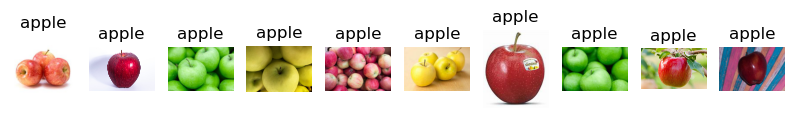

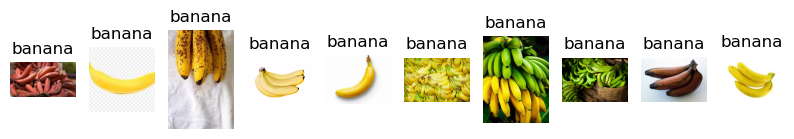

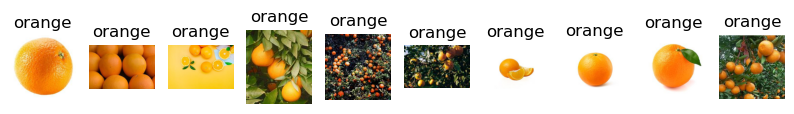

In [50]:
for cls in classes:
    show_random_images(cls, 10)

Color Distribution

In [67]:
def get_mean_rgb_per_class(dataset_path, class_name):
    path = os.path.join(dataset_path, class_name)
    
    all_means = []

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mean_rgb = np.mean(img.reshape(-1, 3), axis=0)
        all_means.append(mean_rgb)
    
    return np.mean(all_means, axis=0)

In [68]:
def get_median_rgb_per_class(dataset_path, class_name):
    path = os.path.join(dataset_path, class_name)
    
    all_means = []

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mean_rgb = np.mean(img.reshape(-1, 3), axis=0)
        all_means.append(mean_rgb)
    
    return np.median(all_means, axis=0)

In [69]:
def show_color(rgb, title=""):
    color = np.array(rgb / 255).reshape(1,1,3)
    
    plt.figure(figsize=(2,2))
    plt.imshow(color)
    plt.title(f"{title}\n{rgb.astype(int)}")
    plt.axis("off")
    plt.show()

apple Mean: [173.7693847  150.23315647 115.30873994]
apple Median: [182.58566667 150.62122926 114.22879747]


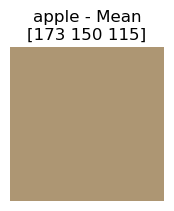

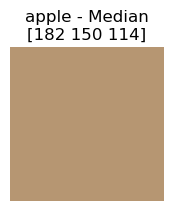

banana Mean: [178.96353951 167.31487526 117.04525674]
banana Median: [182.33986111 162.55949557 109.55675786]


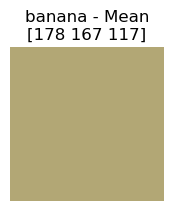

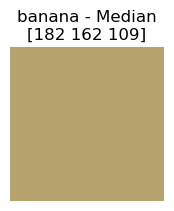

orange Mean: [178.13210352 150.8633273   94.86104799]
orange Median: [188.14305954 140.0922288   78.89658889]


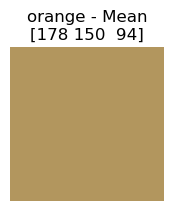

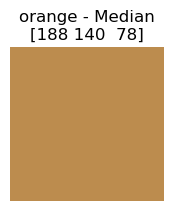

In [70]:
for cls in os.listdir(DATASET_PATH):
    mean_rgb = get_mean_rgb_per_class(DATASET_PATH, cls)
    median_rgb = get_median_rgb_per_class(DATASET_PATH, cls)
    
    print(f"{cls} Mean:", mean_rgb)
    print(f"{cls} Median:", median_rgb)
    
    show_color(mean_rgb, f"{cls} - Mean")
    show_color(median_rgb, f"{cls} - Median")

Image Resolution Distribution

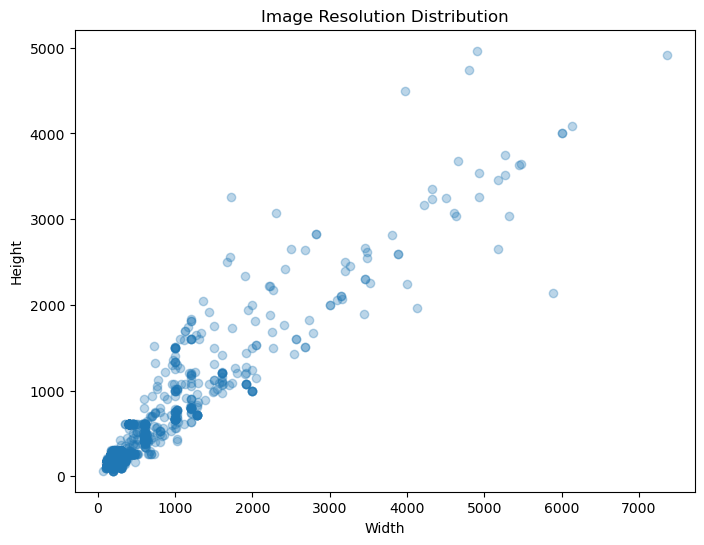

Mean Resolution: 399x328


In [51]:
widths, heights = [], []

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            with Image.open(os.path.join(root, file)) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")
plt.show()

print(f"Mean Resolution: {sum(widths)/len(widths):.0f}x{sum(heights)/len(heights):.0f}")

In [72]:
def detect_outliers(path, min_dim=150, max_ratio=2.0):
    outlier_list = []
    
    for root, _, files in os.walk(path):
        for file in files:
            file_path = os.path.join(root, file)
            cls = os.path.basename(root)
            
            try:
                with Image.open(file_path) as img:
                    w, h = img.size
                    ratio = max(w, h) / min(w, h)
                    size_kb = os.path.getsize(file_path) / 1024
                    
                    reason = []
                    if w < min_dim or h < min_dim: reason.append("Resolution too small")
                    if ratio > max_ratio: reason.append("Aspect ratio extreme")
                    if size_kb < 2: reason.append("File size too tiny")
                    
                    if reason:
                        outlier_list.append({
                            "class": cls,
                            "filename": file,
                            "dim": f"{w}x{h}",
                            "ratio": round(ratio, 2),
                            "size_kb": round(size_kb, 2),
                            "reason": ", ".join(reason)
                        })
            except:
                outlier_list.append({"class": cls, "filename": file, "reason": "Corrupt/Unreadable"})
                
    return pd.DataFrame(outlier_list)

df_outliers = detect_outliers(DATASET_PATH)

if not df_outliers.empty:
    print(f"Total Outliers Found: {len(df_outliers)}")
    print(df_outliers.groupby('reason').size())
    # Menampilkan 10 contoh teratas
    print("\nSample Outliers:")
    print(df_outliers.head(10))
else:
    print("No outliers found with current thresholds.")

Total Outliers Found: 344
reason
Aspect ratio extreme                           15
Resolution too small                          303
Resolution too small, Aspect ratio extreme     22
Resolution too small, File size too tiny        4
dtype: int64

Sample Outliers:
   class           filename      dim  ratio  size_kb  \
0  apple  Dataset_1_107.jpg  129x180   1.40     5.78   
1  apple  Dataset_1_108.jpg  148x180   1.22     4.14   
2  apple  Dataset_1_120.jpg  120x120   1.00     7.37   
3  apple  Dataset_1_127.jpg  139x191   1.37     3.39   
4  apple  Dataset_1_128.jpg  133x180   1.35     3.46   
5  apple  Dataset_1_130.jpg  115x180   1.57     5.46   
6  apple  Dataset_1_131.jpg  143x158   1.10     3.33   
7  apple  Dataset_1_142.jpg  191x129   1.48     5.71   
8  apple  Dataset_1_149.jpg   195x65   3.00     2.41   
9  apple  Dataset_1_150.jpg   195x65   3.00     2.71   

                                       reason  
0                        Resolution too small  
1                      

In [ ]:
REVIEW_DIR = "Review"

count_moved = 0
for _, row in df_outliers.iterrows():
    src_path = os.path.join(DATASET_PATH, row['class'], row['filename'])
    dst_class_dir = os.path.join(REVIEW_DIR, row['class'])
    
    os.makedirs(dst_class_dir, exist_ok=True)
    
    if os.path.exists(src_path):
        shutil.move(src_path, os.path.join(dst_class_dir, row['filename']))
        count_moved += 1

print(f"Success: Moved {count_moved} outliers to {REVIEW_DIR}")

Success: Moved 344 outliers to MergedDataset/Review


In [74]:
for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(DATASET_PATH, cls))))

apple : 1175
banana : 1095
orange : 889


## Splitting Data 80/10/10

In [75]:
import splitfolders

input_folder = "MergedDataset"
output_folder = "FinalDataset"

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .1, .1))

Copying files: 3159 files [00:01, 1936.48 files/s]
